In [1]:
pip install pandas numpy scipy statsmodels scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [25]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import shapiro
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import probplot
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [3]:
df=pd.read_csv("penguins.csv")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [4]:
df.shape

(344, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [6]:
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [7]:
df['island'].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

In [8]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [9]:
species=df.species.value_counts()
species

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

### Task 1: One-Way ANOVA

1. Split the outcome variable into separate arrays (or use a groupby), one per level of the grouping variable.
2. Run a one-way ANOVA using `scipy.stats.f_oneway`.
3. Record the F-statistic and p-value.
4. In a markdown cell, interpret the result:
   - State the null and alternative hypotheses in plain language.
   - Based on the p-value (use α = 0.05), do you reject or fail to reject the null?
   - What does the F-statistic tell you about the ratio of between-group to within-group variance?




In [10]:
df=df.dropna(subset=["species","body_mass_g"])

In [11]:
groups = [group["body_mass_g"].values for name, group in df.groupby("species")]

In [12]:
f_stat, p_value = stats.f_oneway(*groups)

In [13]:
print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 343.62627520548085
p-value: 2.892368133377531e-82


*Null Hypothesis (H0):*  
All penguin species have the same average body mass. 

*Alternative Hypothesis (H1):*

At least one penguin species has a different average body mass.



In [14]:
if p_value < 0.05:
    print("→ Reject H₀: At least one penguin species has a different average body mass.")
else:
    print("→ Fail to reject H₀: All penguin species have the same average body mass.")


→ Reject H₀: At least one penguin species has a different average body mass.


The extremely large F-statistic: 343.63 indicates that the variation between the group means  is much greater than the variation within the groups.  

This suggests that the differences in average body mass across species are not due to random chance, but represent real and substantial differences.


### Task 2: Check ANOVA Assumptions

ANOVA results are only reliable when two key assumptions hold. Test both here.

**Homogeneity of variance (Levene's test):**

1. Run `scipy.stats.levene` on the same groups.
2. Report the test statistic and p-value.
3. Interpret: is the equal-variance assumption reasonable?

**Normality of residuals:**

1. For each group, run the Shapiro-Wilk test (`scipy.stats.shapiro`).
2. Alternatively, compute the ANOVA residuals (observed − group mean) and run Shapiro-Wilk on the pooled residuals.
3. Create a Q-Q plot of the residuals (use `scipy.stats.probplot` or `statsmodels.graphics.gofplots.qqplot`).
4. In a markdown cell, summarize:
   - Do the residuals look approximately normal?
   - If either assumption is violated, what alternatives could you use (e.g., Welch's ANOVA, Kruskal-Wallis)?


In [15]:
levene_stat, levene_p = stats.levene(*groups)
print(f"Levene's test: statistic={levene_stat:.4f}, p={levene_p:.4f}")

Levene's test: statistic=5.1203, p=0.0064


*Null Hypothesis (H0):*  
All groups have equal variances.

*Alternative Hypothesis (H1):*

At least one group has a different variance.

In [16]:
if p_value < 0.05:
    print("→ Reject H₀: At least one group has a different variance.")
else:
    print("→ Fail to reject H₀: All groups have equal variances.")


→ Reject H₀: At least one group has a different variance.


Since the p-value (0.0064) is less than 0.05, we reject the null hypothesis.


In [17]:
for name, group in df.groupby("species"):
    stat, p = shapiro(group["body_mass_g"].dropna())
    print(f"{name} -> Statistic={stat:.4f}, p-value={p:.4f}")

Adelie -> Statistic=0.9807, p-value=0.0324
Chinstrap -> Statistic=0.9845, p-value=0.5605
Gentoo -> Statistic=0.9859, p-value=0.2336


In [18]:
group_means = df.groupby("species")["body_mass_g"].transform("mean")
residuals = df["body_mass_g"] - group_means
residuals = residuals.dropna()

In [19]:
stat, p = shapiro(residuals)

print("Residuals Shapiro Test:")
print("Statistic:", stat)
print("p-value:", p)

Residuals Shapiro Test:
Statistic: 0.9916575409473664
p-value: 0.05118326913958188


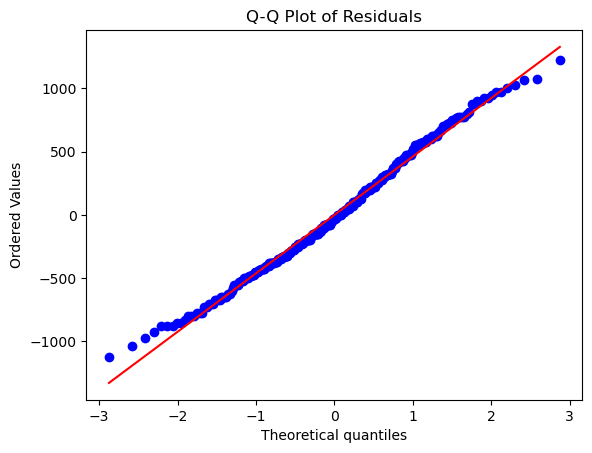

In [20]:
probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

*Null Hypothesis (H0):*
The residuals are normally distributed.

*Alternative Hypothesis (H1):*
The residuals are not normally distributed.

In [23]:
if p < 0.05:
    print(" The residuals are not normally distributed.")
else:
    print("The residuals are normally distributed.")


The residuals are normally distributed.


To evaluate the normality assumption for ANOVA, the Shapiro-Wilk test was applied to the residuals, and a Q-Q plot was used for visual inspection.

*Shapiro-Wilk Test (Residuals):*  
- Statistic = 0.9917  
- p-value = 0.0512  


*Decision (α = 0.05):*
Since the p-value (0.0512) is slightly greater than 0.05, we fail to reject the null hypothesis.

*Interpretation:*
The residuals are approximately normally distributed. Although the p-value is very close to the significance threshold, it does not provide sufficient evidence to conclude non-normality.

*Q-Q Plot:*
The points lie close to the reference line with only minor deviations, supporting the normality assumption.


### Task 3: Tukey HSD Post-Hoc Comparisons

The overall ANOVA F-test tells you that *at least one* group differs, but not *which* groups differ. Post-hoc tests fill that gap.

1. Run Tukey's HSD test using `statsmodels.stats.multicomp.pairwise_tukeyhsd`.
2. Print the results table showing each pairwise comparison, the mean difference, the confidence interval, and the reject/fail-to-reject decision.
3. Create a **mean plot with confidence intervals** (Tukey's HSD provides these) to visualize which groups overlap.
4. In a markdown cell, answer:
   - Which specific group pairs have significantly different means?
   - Which pairs are *not* significantly different?
   - Do the confidence intervals help you understand the practical size of the differences?


In [28]:
tukey = pairwise_tukeyhsd(
    endog=df["body_mass_g"],  
    groups=df["species"],      
    alpha=0.05
)
print(tukey)

     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2  meandiff p-adj    lower     upper   reject
--------------------------------------------------------------
   Adelie Chinstrap   32.426 0.8807 -126.5002  191.3522  False
   Adelie    Gentoo 1375.354    0.0 1243.1786 1507.5294   True
Chinstrap    Gentoo 1342.928    0.0  1178.481  1507.375   True
--------------------------------------------------------------


In [29]:
tukey_results = pd.DataFrame(
    data=tukey._results_table.data[1:], 
    columns=tukey._results_table.data[0]
)

tukey_results

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Adelie,Chinstrap,32.426,0.8807,-126.5002,191.3522,False
1,Adelie,Gentoo,1375.354,0.0000,1243.1786,1507.5294,True
2,Chinstrap,Gentoo,1342.928,0.0000,1178.4810,1507.3750,True


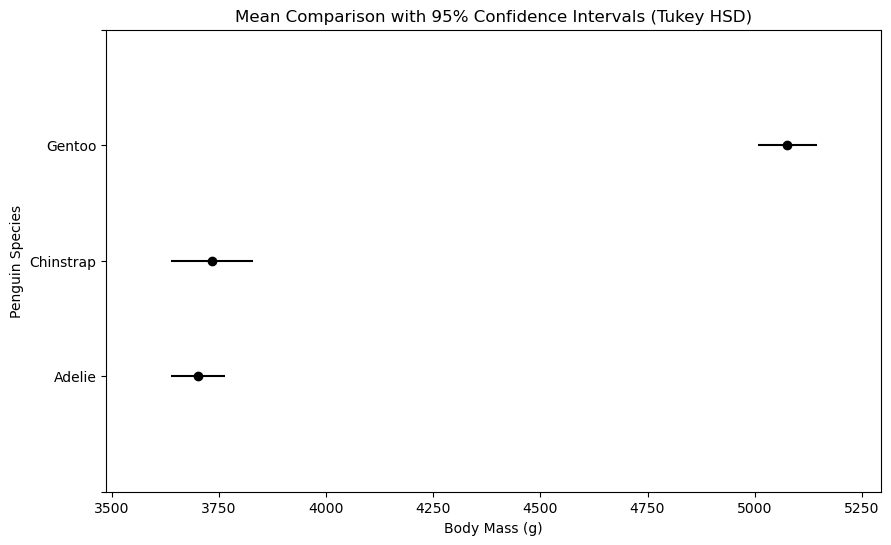

In [31]:
tukey.plot_simultaneous()

plt.title("Mean Comparison with 95% Confidence Intervals (Tukey HSD)")
plt.xlabel("Body Mass (g)")
plt.ylabel("Penguin Species")

plt.show()

In [32]:
tukey_results["decision"] = tukey_results["reject"].apply(
    lambda x: "Reject H0" if x else "Fail to Reject H0"
)

tukey_results

,group1,group2,meandiff,p-adj,lower,upper,reject,decision
0,Adelie,Chinstrap,32.426,0.8807,-126.5002,191.3522,False,Fail to Reject H0
1,Adelie,Gentoo,1375.354,0.0000,1243.1786,1507.5294,True,Reject H0
2,Chinstrap,Gentoo,1342.928,0.0000,1178.4810,1507.3750,True,Reject H0


The Tukey HSD test was used to identify which specific penguin species differ in their average body mass.

*Significantly Different Pairs (reject = True):*
- Adelie vs Gentoo  
- Chinstrap vs Gentoo  

These pairs show statistically significant differences in mean body mass.

*Not Significantly Different Pair (reject = False):*
- Adelie vs Chinstrap  

This indicates that the average body mass of Adelie and Chinstrap penguins is not significantly different.

*Interpretation of Mean Differences:*
- Gentoo penguins are substantially heavier than both Adelie and Chinstrap (difference ≈ 1300–1400 g).
- The difference between Adelie and Chinstrap is very small (≈ 32 g), which explains why it is not statistically significant.

*Confidence Intervals:*
The confidence intervals provide insight into the practical size of the differences:
- For comparisons involving Gentoo, the intervals are far from zero → indicating large and meaningful differences.
- For Adelie vs Chinstrap, the interval includes zero → indicating no clear difference.
